# AICE 모의고사 3회 - 대출 상환 예측

## 문제 시나리오

대출 신청자의 개인 정보 및 금융 데이터를 분석 및 전처리한 후 머신러닝과 딥러닝으로 대출 상환 가능성 점수를 예측하고 결과를 분석하세요. (상환 가능성 점수는 0-100 사이의 숫자 값)

---

## 3-1 | 라이브러리 임포트 및 데이터 로딩

### 【 문제 】

- scikit-learn을 sk로, pandas를 pd로 임포트하세요.
- loan_applicants.json을 읽어 df_applicants에 저장하세요.
- financial_history.csv를 읽어 df_history에 저장하세요.


In [75]:
# 라이브러리 임포트
import sklearn as sk
import pandas as pd

In [76]:
# 데이터 불러오기
df_applicants = pd.read_json('C:/juehyeon/aice_test/기출문제/3.대출상환예측/loan_applicants.json')
df_history = pd.read_csv('C:/juehyeon/aice_test/기출문제/3.대출상환예측/financial_history.csv')

In [77]:
# 데이터 확인하기
df_applicants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ApplicantID      120 non-null    int64  
 1   Age              120 non-null    int64  
 2   Income_USD       120 non-null    int64  
 3   CreditScore      115 non-null    float64
 4   LoanAmount_USD   120 non-null    int64  
 5   LoanTerm_months  120 non-null    int64  
 6   EmploymentType   120 non-null    object 
 7   EducationLevel   120 non-null    object 
dtypes: float64(1), int64(5), object(2)
memory usage: 7.6+ KB


In [78]:
df_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ApplicantID           117 non-null    float64
 1   NumCreditCards        120 non-null    int64  
 2   DebtToIncomeRatio     120 non-null    float64
 3   PreviousLoanDefaults  120 non-null    int64  
 4   AnnualIncome          114 non-null    float64
 5   RepaymentScore        120 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 5.8 KB


## 3-2 | 데이터 병합 및 초기 탐색

### 【 문제 】

- ApplicantID 기준으로 inner join하여 df 생성하세요.
- df.info( )와 df.head( )로 데이터 기본 구조를 확인하세요.
1

In [79]:
# 데이터 병합하기
df = pd.merge(df_applicants, df_history, how = 'inner', on = 'ApplicantID')
# 데이터 구조 확인하기
df.info() #결측치 : CreditScore - 5개

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117 entries, 0 to 116
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ApplicantID           117 non-null    int64  
 1   Age                   117 non-null    int64  
 2   Income_USD            117 non-null    int64  
 3   CreditScore           112 non-null    float64
 4   LoanAmount_USD        117 non-null    int64  
 5   LoanTerm_months       117 non-null    int64  
 6   EmploymentType        117 non-null    object 
 7   EducationLevel        117 non-null    object 
 8   NumCreditCards        117 non-null    int64  
 9   DebtToIncomeRatio     117 non-null    float64
 10  PreviousLoanDefaults  117 non-null    int64  
 11  AnnualIncome          111 non-null    float64
 12  RepaymentScore        117 non-null    int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 12.0+ KB


In [80]:
# 데이터 상위 5개 확인
df.head()

,ApplicantID,Age,Income_USD,CreditScore,LoanAmount_USD,LoanTerm_months,EmploymentType,EducationLevel,NumCreditCards,DebtToIncomeRatio,PreviousLoanDefaults,AnnualIncome,RepaymentScore
0,1,36,161932,406.0,81820,24,Salaried,Masters,1,0.16,3,160462.0,71
1,2,45,117498,672.0,49131,36,Salaried,Bachelors,1,0.19,2,115058.0,78
2,3,51,89735,685.0,10311,48,Salaried,HighSchool,7,0.39,3,90203.0,67
3,4,43,105305,NaN,98016,12,Self-Employed,Masters,2,0.50,1,107246.0,67
4,5,49,142537,489.0,89654,36,Self-Employed,PhD,4,0.19,2,145083.0,62


## 3-3 | 범주형 변수 로트 시각화 및 데이터 경제

### 【 문제 】

- EmploymentType 분포를 countplot으로 시각화하세요.
- EmploymentType 값 중 'Unemployed'를 가진 행을 삭제하세요.
- 삭제된 행 개수를 답안03에 저장하세요.


In [81]:
# 라이브러리 임포트
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='EmploymentType', ylabel='count'>

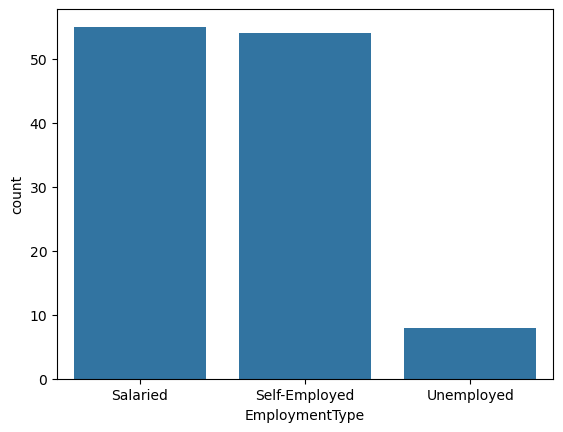

In [82]:
# 데이터 시각화 
sns.countplot(data = df, x = 'EmploymentType')

In [83]:
# 삭제행 갯수
답안03 = (df['EmploymentType'] == 'Unemployed').sum()
# 해당 데이터 행 삭제
df = df[df['EmploymentType'] != 'Unemployed']

In [84]:
# 데이터 삭제 확인
df['EmploymentType'].unique()

array(['Salaried', 'Self-Employed'], dtype=object)


## 3-4 | 수치형 변수 관계 시각화 및 이상치 탐색

### 【 문제 】

- Income_USD와 RepaymentScore의 jointplot을 그리세요.
- Income_USD ≥ 300000을 이상치로 간주하고 개수를 답안04에 저장하세요.

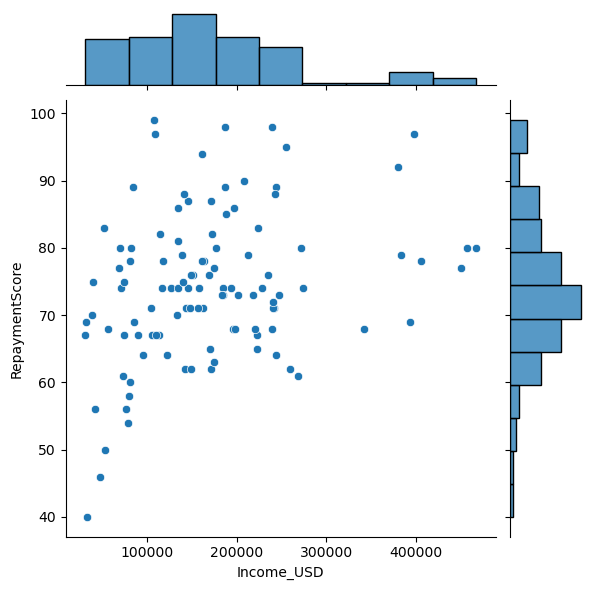

In [85]:
# 데이터 시각화
sns.jointplot(data = df, x = 'Income_USD', y = 'RepaymentScore')
plt.show()

In [86]:
# 이상치 개수 
답안04 = (df['Income_USD'] >= 300000).sum()
print(답안04)

9


## 3-5 | 이상치 및 불필요 컬럼 처리

### 【 문제 】

- Income_USD ≥ 300000 이상치를 제거하세요.
- ApplicantID 컬럼을 삭제하세요.
- 결과를 df_temp에 저장하세요.


In [87]:
# 이상치 제거하기
df = df[df['Income_USD'] < 300000]

In [88]:
# 이상치 제거 확인 (1)
df['Income_USD'].max()

273490

In [89]:
# 이상치 제거 확인(2)
(df['Income_USD'] >= 300000).sum()

np.int64(0)

In [90]:
# 컬럼 삭제하기
df = df.drop(columns = 'ApplicantID')

In [91]:
# 컬럼 삭제 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 0 to 116
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   100 non-null    int64  
 1   Income_USD            100 non-null    int64  
 2   CreditScore           96 non-null     float64
 3   LoanAmount_USD        100 non-null    int64  
 4   LoanTerm_months       100 non-null    int64  
 5   EmploymentType        100 non-null    object 
 6   EducationLevel        100 non-null    object 
 7   NumCreditCards        100 non-null    int64  
 8   DebtToIncomeRatio     100 non-null    float64
 9   PreviousLoanDefaults  100 non-null    int64  
 10  AnnualIncome          94 non-null     float64
 11  RepaymentScore        100 non-null    int64  
dtypes: float64(3), int64(7), object(2)
memory usage: 10.2+ KB


In [92]:
# 변수 재할당
df_temp = df.copy()

## 3-6 | 결측치 처리 및 데이터 타입 변환

### 【 문제 】

- 결측치를 확인하고, AnnualIncome과 CreditScore 컬럼에 있는 결측치를 각 컬럼의 평균값으로 대체하세요.
- 결과를 df_na에 저장하고, 결측치가 대체된 총 개수를 답안06에 저장하세요.

In [93]:
# 결측치 확인
df_temp.isna().sum()

Age                     0
Income_USD              0
CreditScore             4
LoanAmount_USD          0
LoanTerm_months         0
EmploymentType          0
EducationLevel          0
NumCreditCards          0
DebtToIncomeRatio       0
PreviousLoanDefaults    0
AnnualIncome            6
RepaymentScore          0
dtype: int64

In [94]:
# 결측치 개수
before_na = df_temp.isna().sum().sum()
print(before_na)

10


In [95]:
# 결측치 대체하기
na_cols = ['AnnualIncome', 'CreditScore']
df_temp[na_cols] = df_temp[na_cols].fillna(df_temp[na_cols].mean())

In [96]:
# 삭제된 결측치 확인
df_temp.isna().sum()

Age                     0
Income_USD              0
CreditScore             0
LoanAmount_USD          0
LoanTerm_months         0
EmploymentType          0
EducationLevel          0
NumCreditCards          0
DebtToIncomeRatio       0
PreviousLoanDefaults    0
AnnualIncome            0
RepaymentScore          0
dtype: int64

In [97]:
# 변수 재할당
df_na = df_temp.copy()

In [98]:
# 삭제된 결측치 개수
답안06 = (before_na - (df_na.isna().sum().sum()))
print(답안06)

10


## 3-7 | 불필요 컬럼 처리 및 원-핫 인코딩

### 【 문제 】

- EmploymentType, EducationLevel을 원-핫 인코딩하세요.
- 결과를 df_encoded에 저장하세요.


In [99]:
# 원핫 인코딩하기
encod_cols = ['EmploymentType', 'EducationLevel']
df_na = pd.get_dummies(data = df_na, columns = encod_cols)

In [101]:
# 인코딩 확인하기
df_na.columns

Index(['Age', 'Income_USD', 'CreditScore', 'LoanAmount_USD', 'LoanTerm_months',
       'NumCreditCards', 'DebtToIncomeRatio', 'PreviousLoanDefaults',
       'AnnualIncome', 'RepaymentScore', 'EmploymentType_Salaried',
       'EmploymentType_Self-Employed', 'EducationLevel_Bachelors',
       'EducationLevel_HighSchool', 'EducationLevel_Masters',
       'EducationLevel_PhD'],
      dtype='object')

In [103]:
# 변수 재할당
df_encoded = df_na.copy()

## 3-8 | 데이터 분리 및 스케일링

### 【 문제 】

- RepaymentScore를 y로, 나머지를 X로 설정하세요.
- train_test_split으로 80:20 분할하고 random_state=42로 설정하세요.
- StandardScaler로 스케일링하세요.

In [104]:
# 데이터 분리
X = df_encoded.drop(columns = 'RepaymentScore')
y = df_encoded['RepaymentScore']

In [122]:
# 라이브러리 임포트
from sklearn.model_selection import train_test_split

In [123]:
# 훈련, 검증 데이터 분리
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state = 42, test_size = 0.2)

In [124]:
# 데이터 분리 확인
print(X_train.shape, X_valid.shape, y_train.shape, y_valid.shape)

(80, 15) (20, 15) (80,) (20,)


In [125]:
# 스케일링 모델 임포트
from sklearn.preprocessing import StandardScaler

In [126]:
# 모델 객체 생성
scaler = StandardScaler()

In [127]:
# 데이터 스케일링
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)


## 3-9 | 머신러닝 모델 학습(Linear Regression)

### 【 문제 】

- sklearn.linear_model에서 LinearRegression을 임포트하세요.
- 학습 데이터를 이용해 linreg_model을 학습시키세요.


In [128]:
# 라이브러리 임포트
from sklearn.linear_model import LinearRegression

In [129]:
# 모델 객체 생성
linreg_model = LinearRegression()

In [130]:
# 데이터 학습
linreg_model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 3-10 | 머신러닝 모델 학습(XGBoost Regressor)

### 【 문제 】

- xgboost에서 XGBRegressor를 임포트하세요.
- random_state=42, n_estimators=200, learning_rate=0.1로 설정하세요.
- 학습 데이터를 이용해 xgb_model을 학습시키세요.


In [131]:
# 라이브러리 임포트
from xgboost import XGBRegressor

In [132]:
# 모델 객체 생성
xgb_model = XGBRegressor(random_state = 42, n_estimators = 200, learning_rate = 0.1)

In [133]:
# 모델 학습하기
xgb_model.fit(X_train_scaled, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


## 3-11 | 모델 성능 평가(MAE, RMSE, R² 계산)

### 【 문제 】

- 학습된 linreg_model과 xgb_model의 검증 데이터 예측 결과를 평가하세요.
- MAE, RMSE, R²를 각각 계산해 출력하세요.


In [137]:
# 라이브러리 임포트
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [138]:
# 예측 
linreg_pred = linreg_model.predict(X_valid_scaled)
xgb_pred = xgb_model.predict(X_valid_scaled)

In [139]:
# 검증
## mae
linreg_mae = mean_absolute_error(y_valid, linreg_pred)
xgb_mae = mean_absolute_error(y_valid, xgb_pred)

## rmse
linreg_rmse = root_mean_squared_error(y_valid, linreg_pred)
xgb_rmse = root_mean_squared_error(y_valid, xgb_pred)

## r2 score
linreg_r2 = r2_score(y_valid, linreg_pred)
xgb_r2 = r2_score(y_valid, xgb_pred)

In [141]:
## 출력
print(f'Linear Regression \nMAE : {linreg_mae}, RMSE : {linreg_rmse}, R2 Score : {linreg_r2}')

Linear Regression 
MAE : 7.917721919746237, RMSE : 10.101855807684323, R2 Score : 0.020657478318181544


In [142]:
print(f'XGBoost \nMAE : {xgb_mae}, RMSE : {xgb_rmse}, R2 Score : {xgb_r2}')

XGBoost 
MAE : 7.256470680236816, RMSE : 8.817371368408203, R2 Score : 0.25387686491012573



## 3-12 | 딥러닝 모델 개발 및 학습

### 【 문제 】

- tensorflow/keras를 이용해 입력층-은닉층(Dense+Dropout)-출력층(Dense 1) 구조를 만드세요.
- 은닉 2개 이상, 활성화 함수는 ReLU, 드롭아웃 비율은 0.2로 설정하세요.
- 은닉층 2개 이상, 활성화 함수는 ReLU, 드롭아웃 비율은 0.2로 설정하세요.
- 옵티마이저 adam, 손실 함수 MSE, 평가지표 MSE로 컴파일하세요.
- epochs=20, batch_size=16으로 학습하고 history를 저장하세요.

In [143]:
# 라이브러리 임포트
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.models import Sequential

In [145]:
# 모델 객체 생성
dl_model = Sequential([
    Input(shape = (X_train_scaled.shape[1],)),
    Dense(64, activation = 'relu'),
    Dropout(0.2),
    Dense(32, activation = 'relu'),
    Dropout(0.2),
    Dense(1)
])

In [147]:
# 모델 컴파일
dl_model.compile(
    optimizer = 'adam',
    loss = 'mse',
    metrics = ['mse']
)

In [150]:
# 모델 학습
history = dl_model.fit(
    X_train_scaled,
    y_train,
    validation_data = (X_valid_scaled, y_valid),
    epochs = 20, 
    batch_size = 16
)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 2978.7292 - mse: 2978.7292 - val_loss: 2992.2229 - val_mse: 2992.2229
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 2788.9380 - mse: 2788.9380 - val_loss: 2776.8030 - val_mse: 2776.8030
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 2561.7773 - mse: 2561.7773 - val_loss: 2559.2825 - val_mse: 2559.2825
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2351.8337 - mse: 2351.8337 - val_loss: 2340.1108 - val_mse: 2340.1108
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2100.1819 - mse: 2100.1819 - val_loss: 2120.9534 - val_mse: 2120.9534
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1894.7535 - mse: 1894.7535 - val_loss: 1902.9675 - val_mse: 1902.9675
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1592.8870 - mse: 1592.8870 - val_loss: 1692.0970 - val_mse: 1692.0970
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1457.4968 - mse: 1457.4968 - val_loss: 1490.5483 - val

## 3-13 | 딥러닝 학습 곡선 시각화

### 【 문제 】

- history의 mse와 val_mse를 시각화하세요.
- Epochs에 따른 학습/검증 MSE 추이를 같은 그래프에 표시하세요.

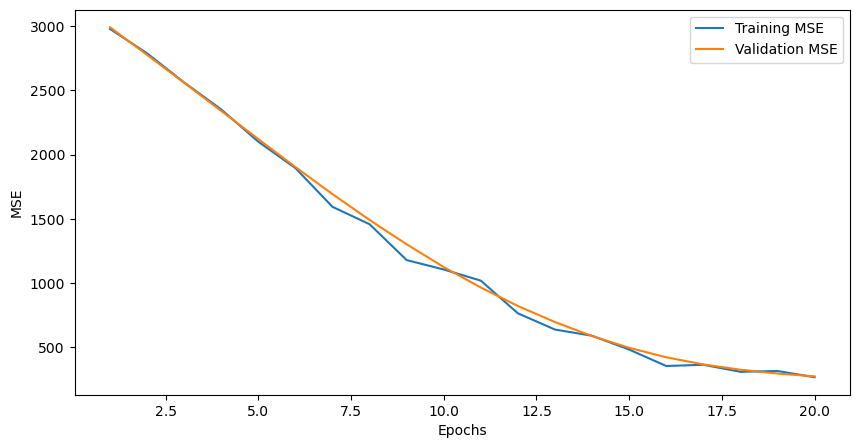

In [154]:
#  데이터 시각화
mse = history.history['mse']
val_mse = history.history['val_mse']
epochs = range(1, len(mse)+1)

plt.figure(figsize=(10,5))
plt.plot(epochs, mse, label='Training MSE')
plt.plot(epochs, val_mse, label='Validation MSE')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()


## 3-14 | 최종 모델 선택 및 결론 도출

### 【 문제 】

- linreg_model, xgb_model, dl_model의 MAE를 비교하세요.
- 가장 낮은 MAE를 보인 모델명을 답안14에 문자열로 저장하세요.
- 성능이 비슷하더라도 해석 가능성, 학습 시간, 배포 용이성 관점에서 실무 권장을 주석으로 작성하세요.

In [155]:
# 데이터 학습
dl_pred = dl_model.predict(X_valid_scaled)
dl_mae = mean_absolute_error(y_valid, dl_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


In [158]:
# mae 비교
print(f'Linear Regression : {linreg_mae}, XGBoost : {xgb_mae}, Deep Learning : {dl_mae}')

Linear Regression : 7.917721919746237, XGBoost : 7.256470680236816, Deep Learning : 13.679327011108398


In [159]:
답안14 = 'XGBoost'